In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.colors as mcolors
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import shap

In [2]:
dataset_path = 'Datasets/Dataset_BA1B.xlsx'

df = pd.read_excel(dataset_path)
# df.dropna(inplace=True)
# df['TOP_DEPTH'].fillna(method='ffill', inplace=True)
[c for c in df.columns]
geology_columns = ['UNIT_TYPE_Dunite',
 'UNIT_TYPE_Fault rock',
 'UNIT_TYPE_Gabbro',
 'UNIT_TYPE_Harzburgite',
 'UNIT_TYPE_Metagabbro',
 'UNIT_TYPE_Other',
'TOP_DEPTH'
 # 'UNIT_CLASS_OPHIO',
 # 'UNIT_CLASS_UND',
                  ]

In [3]:
df.dropna(subset='TOP_DEPTH', inplace=True)
# df.drop_duplicates(subset='TOP_DEPTH', inplace=True)
df.sort_values(by='TOP_DEPTH', inplace=True)
df.reset_index(inplace=True)

In [4]:
[c for c in df.columns]

columns_dont_use = ['CORE',
 'SECTION',
 'IMAGES',
 'SEGMENTATION',
 'TOP_DEPTH',
 'ALTERATION',
 'REMARKS1',
 'REMARKS2',
 'REMARKS4',
 'REMARKS5',
 'Alteration_dummies_50%-90%',
'Alteration_dummies_>90%',
'SECTION_UNIT']

In [5]:
def meow_reg(df, X_cols, Y_col):
    from catboost import CatBoostRegressor, Pool
    from sklearn.metrics import mean_squared_error, r2_score

    X = df[X_cols]
    y = df[Y_col]
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    train_pool = Pool(X_train, y_train)
    eval_pool = Pool(X_test, y_test)
    
    # Instantiate the CatBoost regressor
    catboost_reg = CatBoostRegressor(iterations=1000, learning_rate=0.1, depth=2, loss_function='RMSE')
    
    # Fit the model to the training data
    catboost_reg.fit(X_train, y_train, eval_set=eval_pool, verbose=100, early_stopping_rounds=10)
    
    # Predict on the test data
    y_pred = catboost_reg.predict(X_test)
    
    # Calculate the Mean Squared Error
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error:", mse)
    print('r2 score:', r2_score(y_test, y_pred))
    print('\n')
    return catboost_reg

In [6]:
physics = ['Mean dry electrical Resistivity (ohmm)',
 'AMS bulk susceptibility',]
print('---catboost for physics---')
phys = meow_reg(df=df, X_cols=physics, Y_col='Bulk density (g/cm³)')


---catboost for physics---
0:	learn: 0.1299830	test: 0.1215530	best: 0.1215530 (0)	total: 55.8ms	remaining: 55.7s
100:	learn: 0.0731613	test: 0.0734999	best: 0.0734999 (100)	total: 67.1ms	remaining: 598ms
200:	learn: 0.0536704	test: 0.0596812	best: 0.0596812 (200)	total: 76.4ms	remaining: 304ms
300:	learn: 0.0439171	test: 0.0532869	best: 0.0532869 (300)	total: 84.9ms	remaining: 197ms
400:	learn: 0.0369543	test: 0.0484579	best: 0.0484579 (400)	total: 95.1ms	remaining: 142ms
500:	learn: 0.0318173	test: 0.0457866	best: 0.0457866 (499)	total: 105ms	remaining: 105ms
Stopped by overfitting detector  (10 iterations wait)

bestTest = 0.04406113432
bestIteration = 584

Shrink model to first 585 iterations.
Mean Squared Error: 0.001941383915494284
r2 score: 0.8702128220270504




In [7]:
# from catboost import CatBoostRegressor
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error, r2_score
physics = ['Mean dry electrical Resistivity (ohmm)',
 'AMS bulk susceptibility',]
X = df[physics]
y = df['Bulk density (g/cm³)']


# # Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Predict on the test data
y_pred = phys.predict(X_test)

# # Calculate the Mean Squared Error
# mse = mean_squared_error(y_test, y_pred)
# print("Mean Squared Error:", mse)
# print('r2 score:', r2_score(y_test, y_pred))

In [8]:
import numpy as np
from scipy.signal import find_peaks

def find_peaks_custom(signal):
    # Find peaks greater than 0.1
    positive_peaks, _ = find_peaks(signal, height=0.1)
    
    # Find peaks less than -0.1 (invert the signal to treat troughs as peaks)
    negative_peaks, _ = find_peaks(-signal, height=0.1)
    
    return positive_peaks, negative_peaks


positive interaction peaks [279]
negative interaction peaks [62 67]


/var/folders/93/x6b4gbcn51sfzw4hllq1kt000000gn/T/ipykernel_67716/522559234.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


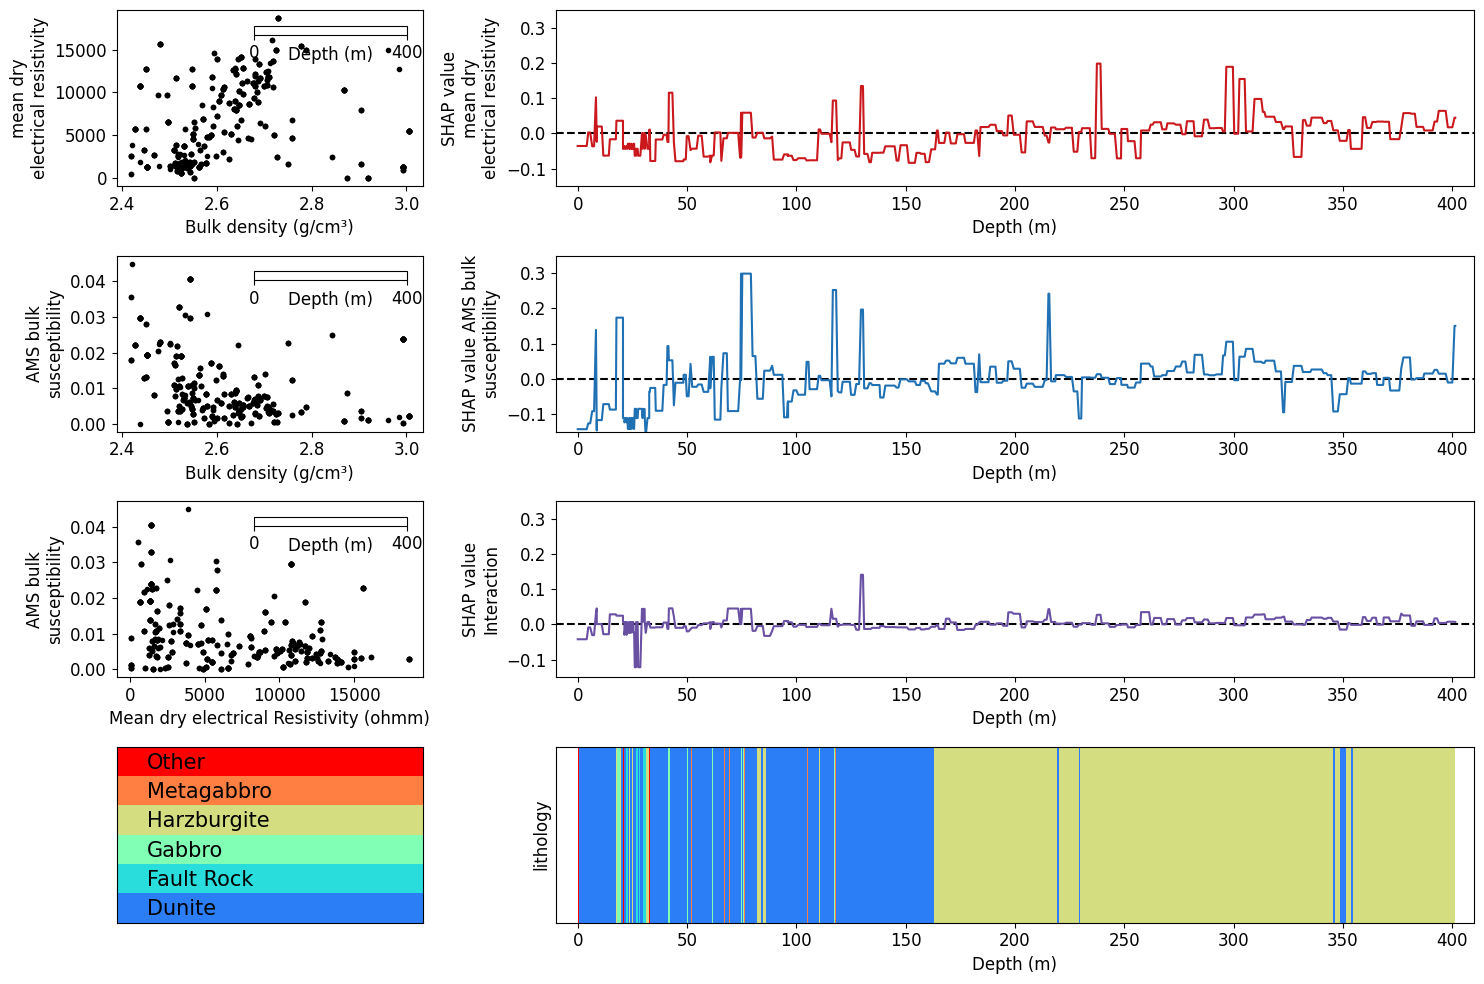

In [17]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import BoundaryNorm

plt.rcParams['font.size'] = 12


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 2, gridspec_kw={'width_ratios': [3, 9]}, figsize=(15, 10))


# calculate shap values
physics = ['Mean dry electrical Resistivity (ohmm)', 'AMS bulk susceptibility',]
X = df[physics]
y = df['Bulk density (g/cm³)']
explainer = shap.TreeExplainer(phys)
shap_values = explainer(X)
shap_df = pd.DataFrame(columns=X.columns, index=df['TOP_DEPTH'])
for n, c in enumerate(X.columns):
    shap_df[c] = shap_values[:,n].values
shap_interaction_values = explainer.shap_interaction_values(X)

def put_newline_in_string_middle(inputstr):
    strlen = len(inputstr)
    closest_middle_from_right = inputstr.rfind(' ', 0, strlen//2)
    return inputstr[0:closest_middle_from_right] + '\n' + inputstr[closest_middle_from_right+1:]

def plot_scatter_and_shap(rawdata, shapdf, ycol, axrow, colormap):

        # plot left panel raw data scatter plot
    bounds = [0, 100, 200, 300, 400]
    norm = BoundaryNorm(bounds, ncolors=plt.cm.viridis.N, clip=True)

    # sc = axrow[0].scatter(rawdata[physics[0]], rawdata[physics[1]]
    # sc = axrow[0].scatter(rawdata['Bulk density (g/cm³)'], rawdata[physics[1]]
    sc = axrow[0].scatter(rawdata['Bulk density (g/cm³)'], rawdata[ycol]
                          # , c=rawdata.TOP_DEPTH, cmap=colormap
                          , color='black'
                          , marker='.')
    # plot left panel raw data scatter plot
    # sc = axrow[0].scatter(rawdata['Bulk density (g/cm³)'], rawdata[ycol], c=rawdata.TOP_DEPTH, cmap=colormap, vmin=-200, marker='.')
    axrow[0].set_ylabel(put_newline_in_string_middle(ycol))
    axrow[0].set_xlabel('Bulk density (g/cm³)')
    # Create an inset axis for the colorbar
    cax = inset_axes(axrow[0], width="50%", height="5%", loc='upper right', borderpad=0.95)
    # cax.xaxis.tick_bottom()
    # cax.xaxis.set_label_position('top')
    # Add the colorbar to the inset axis
    # cax.set_yticks([0, 400])
    cb = fig.colorbar(sc, cax=cax, label='Depth (m)', orientation='horizontal')
    cb.set_ticks([0, 400])
    cb.set_label('Depth (m)', labelpad=-12)  # Negative labelpad moves label upwards

    
    # plot right panel model shap values for variable
    axrow[1].plot(shapdf.index, shapdf[ycol], color=colormap(0.75)) 
    axrow[1].set_ylabel('SHAP value '+put_newline_in_string_middle(ycol))
    axrow[1].set_ylim(-0.15, 0.35)
    axrow[1].plot((-10, 410), (0, 0), zorder=0, color='black', linestyle='--')
    axrow[1].set_xlim(-10, 410)
    axrow[1].set_xlabel('Depth (m)')

def plot_scatter_and_shap_interaction(rawdata, shapdf, ycol, axrow, colormap):
    
    # plot left panel raw data scatter plot
    bounds = [0, 100, 200, 300, 400]
    norm = BoundaryNorm(bounds, ncolors=plt.cm.viridis.N, clip=True)

    # sc = axrow[0].scatter(rawdata[physics[0]], rawdata[physics[1]], c=rawdata.TOP_DEPTH, cmap=colormap, vmin=-200, marker='.')
    sc = axrow[0].scatter(rawdata[physics[0]], rawdata[physics[1]]
                          , color='black'
                          # , c=rawdata.TOP_DEPTH, cmap=colormap
                          , marker='.', )
    axrow[0].set_xlabel(physics[0])
    axrow[0].set_ylabel(put_newline_in_string_middle(physics[1]))
    # Create an inset axis for the colorbar
    cax = inset_axes(axrow[0], width="50%", height="5%", loc='upper right', borderpad=0.95)
    # cax.xaxis.tick_bottom()
    # cax.xaxis.set_label_position('top')
    # Add the colorbar to the inset axis
    # cax.set_yticks([0, 400])
    cb = fig.colorbar(sc, cax=cax, label='Depth (m)', orientation='horizontal')
    cb.set_ticks([0, 400])
    # cb.ax.xaxis.set_label_coords(0.5, 1.1)  # x=0.5 centers, y>1 moves label up
    cb.set_label('Depth (m)', labelpad=-12)  # Negative labelpad moves label upwards

    # # plot right panel model shap values for variable
    pos, neg = find_peaks_custom(shap_interaction_values[:,:,1][:,0])
    print(f'positive interaction peaks {pos}')
    print(f'negative interaction peaks {neg}')
    x = shap_df.index[pos].values
    y = shap_interaction_values[:,:,1][:,0][pos]
    axrow[1].plot(shapdf.index, shap_interaction_values[:,:,1][:,0], color=colormap(0.75))
    axrow[1].set_ylabel('SHAP value\n'+ycol)
    axrow[1].set_ylim(-0.15, 0.35)
    axrow[1].plot((-10, 410), (0, 0), zorder=0, color='black', linestyle='--')
    axrow[1].set_xlim(-10, 410)
    axrow[1].set_xlabel('Depth (m)')


plot_scatter_and_shap(rawdata=df, shapdf=shap_df, ycol='Mean dry electrical Resistivity (ohmm)', axrow=ax1, colormap=plt.cm.Reds)
plot_scatter_and_shap(rawdata=df, shapdf=shap_df, ycol='AMS bulk susceptibility', axrow=ax2, colormap=plt.cm.Blues)
plot_scatter_and_shap_interaction(rawdata=df, shapdf=shap_df, ycol='Interaction', axrow=ax3, colormap=plt.cm.Purples)

ax4[0].pcolormesh(np.vstack([1, 2, 3, 4, 5, 6]), cmap='rainbow', vmin=0, vmax=6)
ax4[0].text(s='Dunite', x=0.1, y=0.25, fontsize=15)
ax4[0].text(s='Fault Rock', x=0.1, y=1.25, fontsize=15)
ax4[0].text(s='Gabbro', x=0.1, y=2.25, fontsize=15)
ax4[0].text(s='Harzburgite', x=0.1, y=3.25, fontsize=15)
ax4[0].text(s='Metagabbro', x=0.1, y=4.25, fontsize=15)
ax4[0].text(s='Other', x=0.1, y=5.25, fontsize=15)
# ax.set_xlim(0, 0.6)
ax4[0].set_yticks([])
ax4[0].set_xticks([])

geo_df = df[geology_columns].copy()
geo_df.dropna(inplace=True)

Zs = []

for n, c in enumerate(geology_columns[:-1]):
    n = n + 1
    z = np.vstack(geo_df[c].values*n)
    Zs.append(z)

Z = np.zeros_like(z)
for z in Zs:
    Z += z
    
x = np.array([0, 1])
y = np.vstack(geo_df['TOP_DEPTH'].values)
xx, yy = np.meshgrid(x, y)
    
ax4[1].pcolormesh(yy, xx, Z[:-1], vmin=0, vmax=6, cmap='rainbow', shading='auto')
ax4[1].set_yticks([])
ax4[1].set_ylabel('lithology')
ax4[1].set_xlabel('Depth (m)')
ax4[1].set_xlim(-10, 410)

ax1[0].set_ylabel('mean dry'+'\n'+'electrical resistivity')
ax1[1].set_ylabel('SHAP value' + '\n' + 'mean dry'+'\n'+'electrical resistivity')

fig.tight_layout()
fig.savefig('shap.png', dpi=1200, bbox_inches='tight')

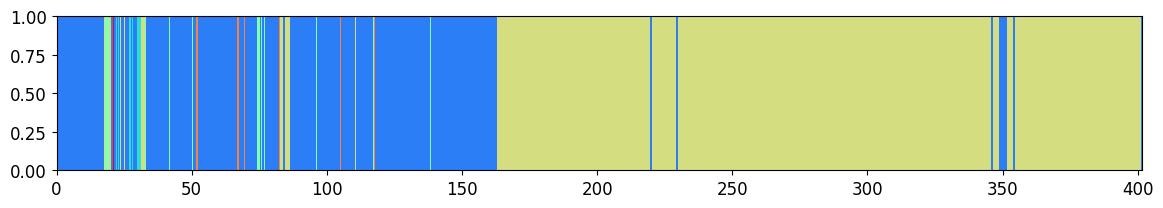

In [10]:
fig, ax = plt.subplots(figsize=(14, 2))
geo_df = df[geology_columns].copy()
geo_df.dropna(inplace=True)

Zs = []

for n, c in enumerate(geology_columns[:-1]):
    n = n + 1
    z = np.vstack(geo_df[c].values*n)
    Zs.append(z)

Z = np.zeros_like(z)
for z in Zs:
    Z += z
    
x = np.array([0, 1])
y = np.vstack(geo_df['TOP_DEPTH'].values)
xx, yy = np.meshgrid(x, y)
    
ax.pcolormesh(yy, xx, Z[:-1], vmin=0, vmax=6, cmap='rainbow', shading='auto')

In [35]:
def put_newline_in_string_middle(inputstr):
    inputstr = inputstr.lower()
    strlen = len(inputstr)
    closest_middle_from_right = inputstr.rfind(' ', 0, strlen//3)
    # return inputstr[0:closest_middle_from_right] + '\n' + inputstr[closest_middle_from_right+1:]
    return '\n'.join(inputstr.split(' '))

print(put_newline_in_string_middle('Mean dry electrical Resistivity (ohmm)'))

mean
dry
electrical
resistivity
(ohmm)


In [28]:
'Mean dry electrical Resistivity (ohmm)'.rfind(' ', 0, 38//2)

8

In [17]:
ycol = physics[1]
pos, neg = find_peaks_custom(shap_df[ycol])

dataset_path = 'Datasets/Dataset_BA1B.xlsx'

df = pd.read_excel(dataset_path)
groups = [
    ['Veins', 'Serpentine vein', 'Carbonate veins', 'White veins', 'Green veins',
     'Blue patches', 'Magmatic veins', 'Dark green', 'Magmatic intrusions',
     'Hydrothermal', 'Offsets', 'Rodingite'],
    ['Oxidation', 'Black serpentinization', 'Alteration', 'Alteration halo',
     'Altered gabbro', 'Altered', 'Pyroxenite'],
    ['Network', 'Coalescence', 'Dyke', 'Shearing', 'Crack'
     ,  'Open cracks'
     , 'Open crack', 'Irregular', 'Subvertical',
     'Subhorizontal', 'Lineation', 'Thickness', 'Offset', 'Fracture',
     'Sheared', 'Striations', 'Branching', 'Slickensides'],
    ['Dunite', 'Gabbro', 'Microgabbro', 'Harzburgite', 'Pxenites', 'Dunitic zone','Magnetite'],
    ['Plagioclase', 'Microbio sample', 'Bulk serp', 'Bulk'],
    ['Fine grained', 'Waxy green', 'Waxy', 'Wavy']
]

words = []
for g in groups:
    for w in g:
        words.append(w)

# print(ycol)
# for p in pos:
for p in [62, 67]:
    row = df.set_index('TOP_DEPTH')[words].iloc[p]
    d = df.TOP_DEPTH.iloc[p]
    print(ycol, ':', f'position {p}', ':', f'depth {d}', ':', 'positive bulk density')
    # for i in row[row==1].index:
    #     print(i)
    print(', '.join(list(row[row==1].index)))
    print('')

AMS bulk susceptibility : position 62 : depth 30.29 : positive bulk density
Serpentine vein, Black serpentinization, Pxenites, Magnetite, Microbio sample, Fine grained

AMS bulk susceptibility : position 67 : depth 31.905 : positive bulk density
Serpentine vein, Carbonate veins, White veins, Pxenites, Magnetite



In [18]:
df.columns

Index(['CORE', 'SECTION', 'Cell abundance (cells/g)',
       'Mean dry electrical Resistivity (ohmm)', 'Bulk density (g/cm³)',
       'AMS bulk susceptibility', 'LOI wt%', 'CO2 wt%', 'H20 wt%',
       'CaCO3 calc',
       ...
       'Crrecal', 'Co', 'Nirecal', 'Curecal', 'Znrecal', 'Srrecal', 'Redness',
       'Greenness', 'Blueness', 'Y (luminance)'],
      dtype='object', length=127)

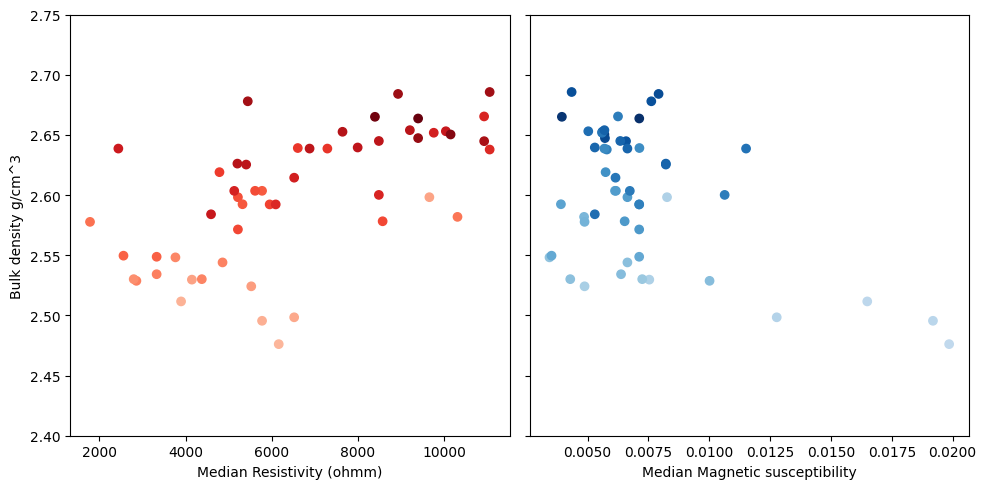

In [19]:
medians = {}
cols = ['Mean dry electrical Resistivity (ohmm)', 'AMS bulk susceptibility', 'Bulk density (g/cm³)', 'TOP_DEPTH']

for w in words:

    med = df[df[w]==1][cols].median()
    medians[w] = {'resist':med[cols[0]], 'magnet':med[cols[1]], 'bd':med[cols[2]], 'depth':med[cols[3]]}

data = pd.DataFrame(medians).transpose()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].scatter(data['resist'], data['bd'], c=data['depth'], cmap='Reds', vmin=-100)
ax[1].scatter(data['magnet'], data['bd'], c=data['depth'], cmap='Blues', vmin=-100)

ax[0].set_ylabel('Bulk density g/cm^3')
ax[0].set_xlabel('Median Resistivity (ohmm)')
ax[1].set_xlabel('Median Magnetic susceptibility')

ax[0].set_ylim(2.4, 2.75)

fig.tight_layout()

In [20]:
# fig, ax = plt.subplots(figsize=(15, 5))

# ax.plot(df.TOP_DEPTH, df['Bulk density (g/cm³)'], label='True', color='limegreen', zorder=0, linewidth=4)


# ax2 = ax.twinx()
# ax2.plot(shap_df.index, shap_df['Mean dry electrical Resistivity (ohmm)'], color='red')
# ax2.plot(shap_df.index, shap_df['AMS bulk susceptibility'])
# ax2.plot(df.TOP_DEPTH, shap_interaction_values[:,:,1][:,0], color='Purple')

# ax2.plot((-10, 410), (0, 0), zorder=0, color='black', linestyle='--')
# ax.set_xlim(-10, 410)

# ax2.legend(['resistivity', 'ams', 'interaction'])
# # ax2.plot(df.TOP_DEPTH,  shap_df['Mean dry electrical Resistivity (ohmm)'] +  shap_df['AMS bulk susceptibility'] + shap_interaction_values[:,:,1][:,0])


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the Linear Regression model
model = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train['interaction'] = X_train['Mean dry electrical Resistivity (ohmm)']*X_train['AMS bulk susceptibility']
X_test['interaction'] = X_test['Mean dry electrical Resistivity (ohmm)']*X_test['AMS bulk susceptibility']


# Fit the model on the training data
model.fit(X_train, y_train)

# Predict on the training data
y_pred = model.predict(X_train)

# Calculate R² score
r2 = r2_score(y_train, y_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_pred))

# Output the results
print(f"R²: {r2}")
print(f"RMSE: {rmse}")


R²: 0.15486737459726285
RMSE: 0.12092934768361109
